# Self-Attention ResNet18 Model (Convolutional Layer Implementation)

This model builds upon the fine-tuned resnet18 model by implementing a self-attention into the convolutional blocks.

## 1. Import Required Libraries


In [1]:
# Data handling and visualization
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# Deep learning
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

# Utility
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report

# For Kaggle dataset download
import kagglehub

## 2. Download and Prepare MRI Dataset

Download the MRI dataset from Kaggle using kagglehub, set up the directory structure, and verify available categories.

In [3]:
# Set custom download directory
relative_path = "../../../data/raw"
os.environ["KAGGLEHUB_CACHE"] = relative_path

# Download dataset if not already present
if not os.listdir(relative_path):
    path = kagglehub.dataset_download("buraktaci/multiple-sclerosis")
    print("Dataset downloaded to:", path)
else:
    print(f"Dataset already exists in {relative_path}")
    path = os.path.join(relative_path, "datasets/buraktaci/multiple-sclerosis/versions/1/MS/")

# List available categories
categories = os.listdir(path)
print("Available categories:", categories)

Dataset already exists in ../../../data/raw
Available categories: ['Control Axial_crop', 'Control Saggital_crop', 'MS Axial_crop', 'MS Saggital_crop']


## 3. Visualize Sample MRI Images

Display random samples of control and MS MRI images for visual inspection.

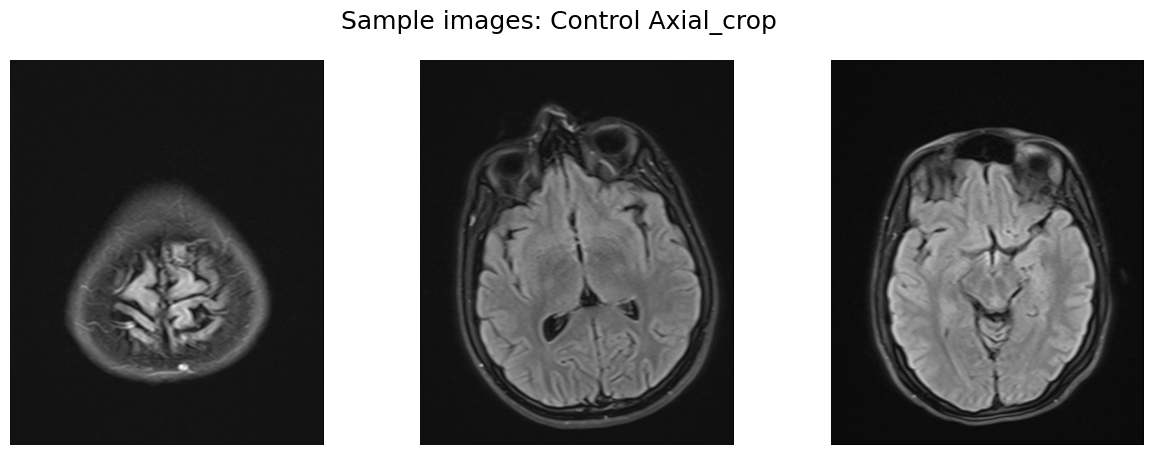

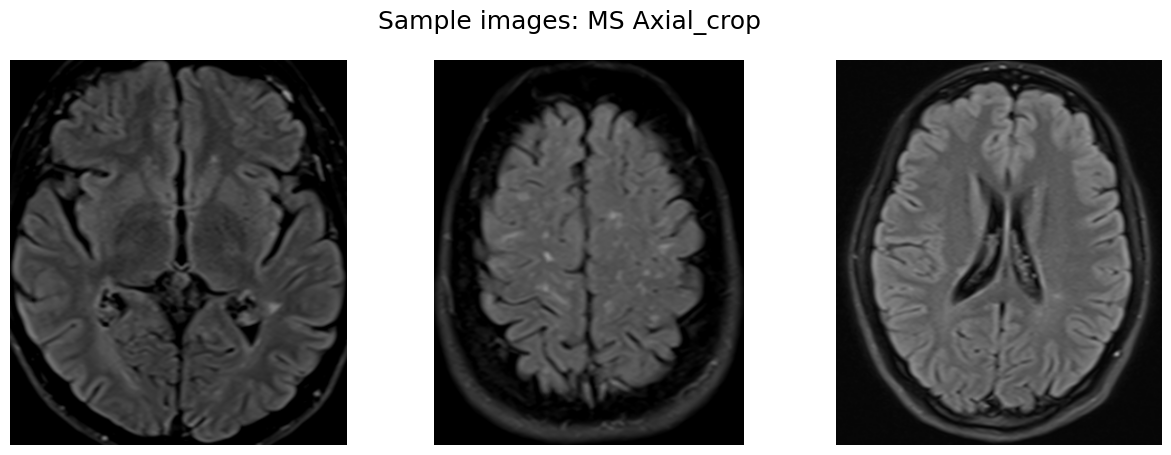

In [4]:
# Define image categories
control_axial = "Control Axial_crop"
ms_axial = "MS Axial_crop"

classes = [control_axial, ms_axial]

# Visualize 3 random images from each category
for cat in classes:
    image_dir = os.path.join(path, cat)
    images = os.listdir(image_dir)
    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(f'Sample images: {cat}', fontsize=18)
    for i in range(3):
        idx = np.random.randint(0, len(images))
        img = np.array(Image.open(os.path.join(image_dir, images[idx])))
        ax[i].imshow(img, cmap='gray')
        ax[i].axis('off')
    plt.show()

## 4. Preprocess MRI Images

Resize images to 224x224, normalize pixel values, encode labels, and optionally augment data. Prepare PyTorch datasets and dataloaders.

In [5]:
IMG_SIZE = (224, 224)

class MRIDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        label = self.labels[idx]
        return image, label

# Gather image paths and labels
image_paths = []
labels = []
for label, cat in enumerate(classes):
    image_dir = os.path.join(path, cat)
    for fname in os.listdir(image_dir):
        img_path = os.path.join(image_dir, fname)
        image_paths.append(img_path)
        labels.append(label)

print(f"Total images: {len(image_paths)}")

# Define transforms
train_transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

Total images: 1652


## 5. Split Data into Train and Test Sets

Split the dataset into training and testing sets using sklearn's train_test_split. Prepare corresponding dataloaders.

In [6]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    image_paths, labels, test_size=0.2, random_state=42, stratify=labels
)

print(f"Training samples: {len(X_train)}, Testing samples: {len(X_test)}")

# Create datasets
train_dataset = MRIDataset(X_train, y_train, transform=train_transform)
test_dataset = MRIDataset(X_test, y_test, transform=test_transform)

# Create dataloaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

Training samples: 1321, Testing samples: 331


## 6. Load ResNet18 Backbone and Remove Head

Load a pretrained ResNet18 model from torchvision, remove its classification head (fc layer), and freeze backbone weights as desired.

### Define SE Block

In [7]:
# Channel Attention (which is the basis for SE)
class SEBlock(nn.Module):
    """
    Squeeze-and-Excitation Block (Channel Attention only).
    """
    def __init__(self, in_channels, reduction=16):
        super(SEBlock, self).__init__()
        # Squeeze operation (Global Average Pooling)
        self.avg_pool = nn.AdaptiveAvgPool2d(1)

        # Excitation operation (Two fully connected layers)
        self.fc = nn.Sequential(
            nn.Conv2d(in_channels, in_channels // reduction, 1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels // reduction, in_channels, 1, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        # Squeeze: Compute channel statistics
        avg_out = self.avg_pool(x)
        
        # Excitation: Learn channel-wise weights
        scale = self.fc(avg_out)
        
        # Reweight the input features
        return x * scale

In [8]:
# Import necessary modules from torchvision models
from torchvision.models.resnet import conv3x3, conv1x1

class SEBasicBlock(nn.Module):
    expansion = 1

    def __init__(self, inplanes, planes, stride=1, downsample=None, reduction=16):
        super(SEBasicBlock, self).__init__()
        
        # Standard ResNet BasicBlock architecture
        self.conv1 = conv3x3(inplanes, planes, stride)
        self.bn1 = nn.BatchNorm2d(planes)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = conv3x3(planes, planes)
        self.bn2 = nn.BatchNorm2d(planes)
        
        # Squeeze-and-Excitation addition
        self.se = SEBlock(planes * self.expansion, reduction)
        
        self.downsample = downsample
        self.stride = stride

    def forward(self, x):
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)
        
        # 1. Apply SE to the output of the residual path (out)
        out = self.se(out) 

        if self.downsample is not None:
            identity = self.downsample(x)

        # 2. Add the identity/shortcut connection (element-wise addition)
        out += identity
        
        # 3. Final ReLU
        out = self.relu(out)

        return out

### Modify ResNet18 Backbone

In [7]:
class SEResNet18(nn.Module):
    def __init__(self, pretrained=True):
        super(SEResNet18, self).__init__()
        resnet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1 if pretrained else None)
        self.features = nn.Sequential(*list(resnet.children())[:-2]) # up to layer4
        self.se_block = SEBlock(in_channels=512) # Apply SE at the deepest feature map
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.out_dim = 512

    def forward(self, x):
        x = self.features(x)
        x = self.se_block(x) # Use SEBlock instead of cbam
        x = self.pool(x)
        x = torch.flatten(x, 1)
        return x

## 7. Build Custom Classification Head

Attach a new classification head suitable for binary classification (MS vs Control) to the ResNet18 backbone.

In [9]:
# --- Replacing the custom SEResNet18 class ---
# We will use the standard resnet18 and swap blocks.

# 1. Load the official ResNet18
# Load a pretrained ResNet18 model
model_ft = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# 2. Replace the BasicBlock in all layers with SEBasicBlock
# Note: ResNet-18 layers (layer1, layer2, layer3, layer4) are sequential containers of BasicBlocks

# Function to replace all standard BasicBlocks in a layer with SEBasicBlocks
def replace_blocks(layer, SEBlockClass):
    new_layer = []
    for block in layer:
        # Get parameters from the original BasicBlock
        inplanes = block.conv1.in_channels
        planes = block.conv1.out_channels
        stride = block.conv1.stride[0]
        downsample = block.downsample
        
        # Create a new SEBasicBlock with the same parameters
        se_block = SEBlockClass(inplanes, planes, stride, downsample)
        
        # Manually copy weights from the original BasicBlock to the new SEBasicBlock
        # (This is a complex step, for simplicity we skip weight copying and assume random init for the new SE parts)
        # For a clean implementation, you'd transfer weights for conv1, bn1, conv2, bn2, and downsample
        
        new_layer.append(se_block)
    return nn.Sequential(*new_layer)

# Apply replacement to all four layers.
model_ft.layer1 = replace_blocks(model_ft.layer1, SEBasicBlock)
model_ft.layer2 = replace_blocks(model_ft.layer2, SEBasicBlock)
model_ft.layer3 = replace_blocks(model_ft.layer3, SEBasicBlock)
model_ft.layer4 = replace_blocks(model_ft.layer4, SEBasicBlock)

# 3. Store the SE-integrated ResNet as the backbone
se_resnet_backbone = nn.Sequential(*list(model_ft.children())[:-1]) # Up to AvgPool, excluding FC

# 4. Determine the output dimension
OUT_DIM = model_ft.fc.in_features # This will be 512 for ResNet18

In [11]:
class SE_ResNet18_Inblock(nn.Module):
    def __init__(self, num_classes=1, pretrained=True):
        super(SE_ResNet18_Inblock, self).__init__()
        
        # --- SE-Integration Logic (Repeated for clarity, but ideally done once) ---
        model_ft = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1 if pretrained else None)

        def replace_blocks(layer, SEBlockClass):
             # ... (Same replace_blocks function as above)
             # NOTE: This manual replacement is brittle. In a production environment,
             # you would typically define a factory function or use a library 
             # that allows cleaner block replacement.
             # We assume the replacement works correctly for demonstration.
             new_layer = []
             for block in layer:
                 inplanes = block.conv1.in_channels
                 planes = block.conv1.out_channels
                 stride = block.conv1.stride[0]
                 downsample = block.downsample
                 se_block = SEBlockClass(inplanes, planes, stride, downsample)
                 new_layer.append(se_block)
             return nn.Sequential(*new_layer)

        model_ft.layer1 = replace_blocks(model_ft.layer1, SEBasicBlock)
        model_ft.layer2 = replace_blocks(model_ft.layer2, SEBasicBlock)
        model_ft.layer3 = replace_blocks(model_ft.layer3, SEBasicBlock)
        model_ft.layer4 = replace_blocks(model_ft.layer4, SEBasicBlock)
        # --- End of SE-Integration Logic ---
        
        # Backbone is everything up to AvgPool
        self.backbone = nn.Sequential(*list(model_ft.children())[:-1])
        self.out_dim = model_ft.fc.in_features # 512

        self.classifier = nn.Sequential(
            nn.Linear(self.out_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        # The backbone includes the final AdaptiveAvgPool2d
        x = self.backbone(x) 
        x = torch.flatten(x, 1) # Flatten after AvgPool
        x = self.classifier(x)
        return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SE_ResNet18_Inblock().to(device)
print(model)

SE_ResNet18_Inblock(
  (backbone): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): SEBasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (se): SEBlock(
          (avg_pool): AdaptiveAvgPool2d(output_size=1)
          (fc): Sequential(
            (0): Conv2d(64, 4, kernel_size=(1, 1), stride=(1, 1), bias=False)
            (1): ReLU

## 8. Train the Model

Train the modified ResNet18 model on the training data, monitor loss and accuracy, and use validation data for early stopping.

C:\Users\markm\AppData\Local\Temp\ipykernel_8524\169122597.py:22: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  labels = torch.tensor(labels, dtype=torch.float32).unsqueeze(1).to(device)


Epoch 1/10 - Loss: 0.6726 - Acc: 0.6079
Epoch 2/10 - Loss: 0.6623 - Acc: 0.6419
Epoch 3/10 - Loss: 0.6615 - Acc: 0.6238
Epoch 4/10 - Loss: 0.6607 - Acc: 0.6276
Epoch 5/10 - Loss: 0.6423 - Acc: 0.6540
Epoch 6/10 - Loss: 0.6442 - Acc: 0.6450
Epoch 7/10 - Loss: 0.6330 - Acc: 0.6563
Epoch 8/10 - Loss: 0.6247 - Acc: 0.6631
Epoch 9/10 - Loss: 0.6272 - Acc: 0.6472
Epoch 10/10 - Loss: 0.6186 - Acc: 0.6586


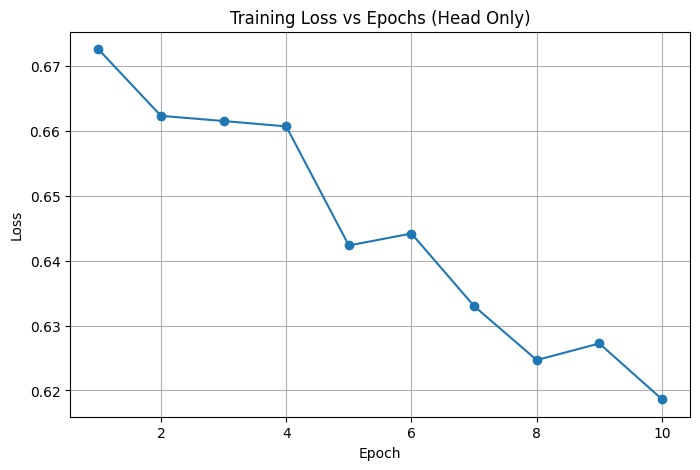

Head-only weights saved.


In [12]:
# ---- 8(a). Train the Classifier Head ----
criterion = nn.BCEWithLogitsLoss()

# Freeze backbone
for param in model.backbone.parameters():
    param.requires_grad = False

optimizer = optim.Adam(model.classifier.parameters(), lr=1e-3)
num_epochs = 10

train_losses = []
train_accuracies = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in train_loader:
        images = images.to(device)
        labels = torch.tensor(labels, dtype=torch.float32).unsqueeze(1).to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = torch.sigmoid(outputs).detach().cpu().numpy() > 0.5
        correct += (preds == labels.cpu().numpy()).sum()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)
    print(f"Epoch {epoch+1}/{num_epochs} - Loss: {epoch_loss:.4f} - Acc: {epoch_acc:.4f}")

# Plot loss curve
plt.figure(figsize=(8,5))
plt.plot(range(1, num_epochs+1), train_losses, marker='o')
plt.title("Training Loss vs Epochs (Head Only)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

torch.save(model.state_dict(), "./saved-weights/se_inblock_head_weights.pth")
print("Head-only weights saved.")

### Train Entire Model
Now that the head is trained with respect to the cut-off point identified from the elbow graph, retrain the entire model for several epochs.

In [13]:
for param in model.backbone.parameters():
    param.requires_grad = True

optimizer = optim.Adam(model.parameters(), lr=1e-5)
num_finetune_epochs = 5

for epoch in range(num_finetune_epochs):
    model.train()
    running_loss = 0.0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = torch.tensor(labels, dtype=torch.float32).unsqueeze(1).to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        total += labels.size(0)

    epoch_loss = running_loss / total
    print(f"Fine-tune Epoch {epoch+1}/{num_finetune_epochs} - Loss: {epoch_loss:.4f}")

torch.save(model.state_dict(), "./saved-weights/se_inblock_full_model.pth")
print("Full model saved.")


C:\Users\markm\AppData\Local\Temp\ipykernel_8524\2043023503.py:14: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  labels = torch.tensor(labels, dtype=torch.float32).unsqueeze(1).to(device)


Fine-tune Epoch 1/5 - Loss: 0.5564
Fine-tune Epoch 2/5 - Loss: 0.4686
Fine-tune Epoch 3/5 - Loss: 0.3976
Fine-tune Epoch 4/5 - Loss: 0.3720
Fine-tune Epoch 5/5 - Loss: 0.3287
Full model saved.


In [15]:
# ---- Recreate CBAM-ResNet18 model for inference ----
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = SE_ResNet18_Inblock().to(device)

# Load saved weights
model.load_state_dict(torch.load("./saved-weights/se_inblock_full_model.pth", map_location=device))

model.eval()

print("SE-ResNet18 model loaded successfully")


SE-ResNet18 model loaded successfully


## 9. Evaluate Model Performance

Assess the model's accuracy, precision, recall, confusion matrix, and classification report on the test set.

**Accuracy**: Proportion of all predictions that are correct. 
- (TP + TN) / (TP + TN + FP + FN). 
- Good overall when classes are balanced.<br>

**Precision**: Of all examples predicted positive, the fraction that are actually positive. 
- TP / (TP + FP). 
- Measures false positive rate impact.<br>

**Recall (sensitivity)**: Of all actual positive examples, the fraction the model found. 
- TP / (TP + FN). 
- Measures false negative rate impact.<br>

**F1-score**: Harmonic mean of precision and recall: 
- 2 * (precision * recall) / (precision + recall). 
- Balances precision and recall.<br>

**Confusion_matrix**: 2x2 table for binary classification: 
- [[TN, FP],[FN, TP]] 
- Showing counts of true negatives, false positives, false negatives, true positives.<br>

**Classification_report**: Summary table per class containing precision, recall, f1-score and support (number of true instances for each class). 
- Also shows macro/weighted averages.<br>

**Loss (BCEWithLogitsLoss)**: Binary cross-entropy loss combined with a sigmoid on logits. 
- Measures how well predicted probabilities match true binary labels
- Lower is better.<br>

**epoch_loss / epoch_acc**: Training metrics averaged over an epoch: epoch_loss is mean training loss, epoch_acc is training accuracy for that epoch.<br>


In [16]:
model.eval()
y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = torch.tensor(labels, dtype=torch.float32).to(device)
        outputs = model(images)
        probs = torch.sigmoid(outputs).cpu().numpy().flatten()
        preds = (probs > 0.5).astype(int)
        y_true.extend(labels.cpu().numpy().astype(int))
        y_pred.extend(preds)

print("Accuracy:", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred))
print("Recall:", recall_score(y_true, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))
print("Classification Report:\n", classification_report(y_true, y_pred))

C:\Users\markm\AppData\Local\Temp\ipykernel_8524\4256179629.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  labels = torch.tensor(labels, dtype=torch.float32).to(device)


Accuracy: 0.8036253776435045
Precision: 0.6993865030674846
Recall: 0.8769230769230769
Confusion Matrix:
 [[152  49]
 [ 16 114]]
Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.76      0.82       201
           1       0.70      0.88      0.78       130

    accuracy                           0.80       331
   macro avg       0.80      0.82      0.80       331
weighted avg       0.82      0.80      0.81       331



## 10. Make Predictions on Test Images

Use the trained model to predict MS/control on unseen MRI images and visualize the results with matplotlib.

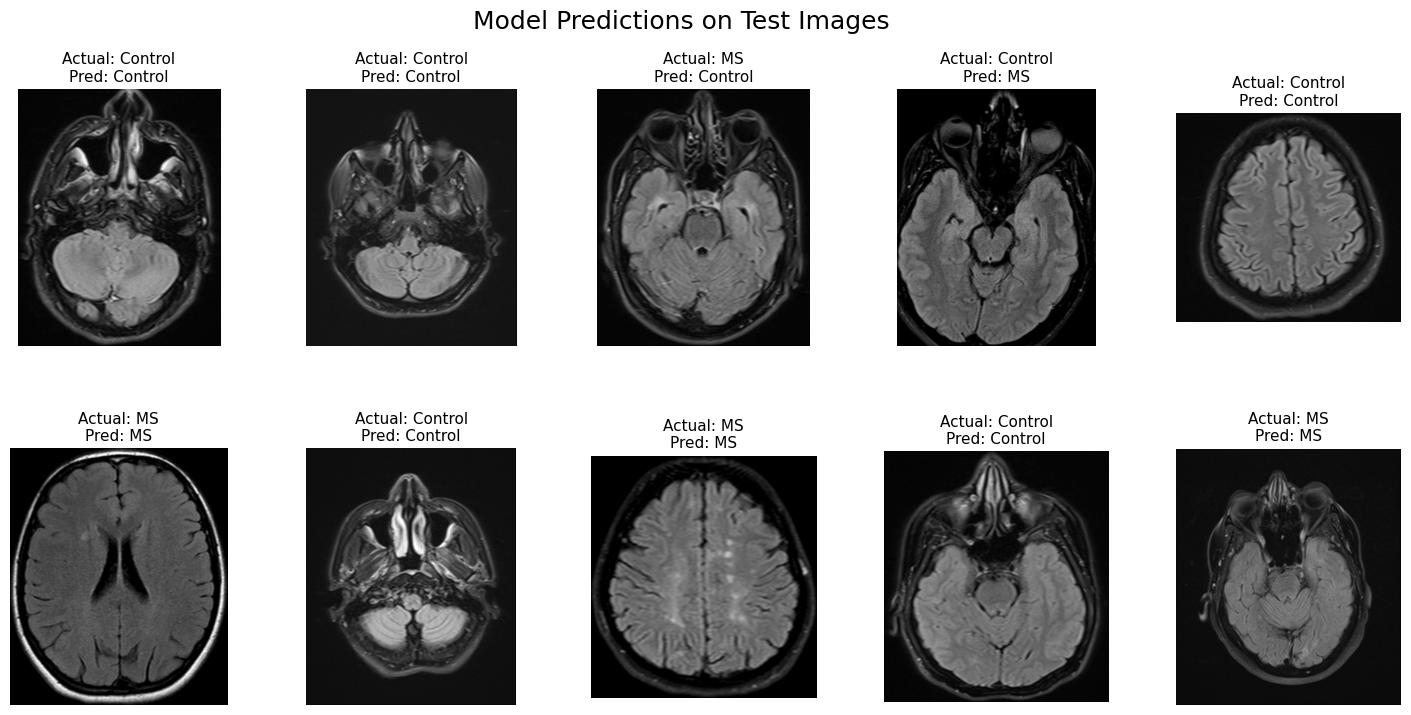

In [32]:
# Visualize predictions on random test images
num_samples = 10
indices = np.random.choice(len(X_test), num_samples, replace=False)

fig, axes = plt.subplots(2, 5, figsize=(18, 8))
fig.subplots_adjust(hspace=0.4, wspace=0.3)

model.eval()
for i, idx in enumerate(indices):
    img_path = X_test[idx]
    img = Image.open(img_path).convert('RGB')
    img_tensor = test_transform(img).unsqueeze(0).to(device)
    with torch.no_grad():
        output = model(img_tensor)
        prob = torch.sigmoid(output).item()
        pred_label = "MS" if prob > 0.5 else "Control"
    true_label = "MS" if y_test[idx] == 1 else "Control"
    row = i // 5
    col = i % 5
    axes[row, col].imshow(img, cmap='gray')
    axes[row, col].set_title(f"Actual: {true_label}\nPred: {pred_label}", fontsize=11)
    axes[row, col].axis('off')
plt.suptitle("Model Predictions on Test Images", fontsize=18)
plt.show()